![image.png](https://i.imgur.com/a3uAqnb.png)

# Football Players Detection with Roboflow and YOLO



📂 Dataset Description

The dataset contains images of football players captured during matches, with diverse poses, backgrounds, and camera angles.
	•	Image size: varies (real match footage)
	•	Content: football players on the field, with varying numbers of players per frame.
	•	Goal: Detect and localize players by drawing bounding boxes around them.

## **📝 Exercise  1**

1.  Download the dataset: https://drive.google.com/file/d/16wCAtOoZn6J24W-yNnrLN6mLjRxjfOye/view?usp=sharing
	*	Download and unzip the images.
2.	Upload to Roboflow
	*	Create a free Roboflow account: https://roboflow.com.
	*	Create a new project (object detection → multi class: ball, goalkeeper, player and referee.).
	* Upload the football images.
3.	Annotate the dataset
	*	Draw bounding boxes around each object in the images.
	*	Label them as ball, goalkeeper, player or referee.
	*	Save annotations once finished.
4.	Generate dataset
	*	In Roboflow, click Generate Dataset.
	*	Choose a split (e.g., 20% train / 10% validation / 10% test).
	*	Export in a format compatible with the preferred model.

## **📝 Exercise  2:**
Train a YOLOv8 Model for Football Player Detection

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("borhanitrash/football-players-detection-dataset")

print("Path to dataset files:", path)

100%|██████████| 68.0M/68.0M [00:04<00:00, 15.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/borhanitrash/football-players-detection-dataset/versions/1


In [ ]:
# Load dataset configuration
dataset_path = path + "/data.yaml"

# Check dataset information
print(open(dataset_path).read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 4
names: ['ball', 'goalkeeper', 'player', 'referee']

roboflow:
  workspace: roboflow-jvuqo
  project: football-players-detection-3zvbc
  version: 9
  license: CC BY 4.0
  url: https://universe.roboflow.com/roboflow-jvuqo/football-players-detection-3zvbc/dataset/9


In [ ]:
# Install Ultralytics library which has Yolo
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 61.9 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
# Load YOLOv8 model (small version)
model = YOLO("yolov8s.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.



image 1/1 /root/.cache/kagglehub/datasets/borhanitrash/football-players-detection-dataset/versions/1/test/images/40cd38_7_6_png.rf.68ef7fcd663cdf0f5b96bacdbcd94e07.jpg: 384x640 17 persons, 44.6ms
Speed: 8.9ms preprocess, 44.6ms inference, 276.7ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict


Text(0.5, 1.0, 'Predicted Image')

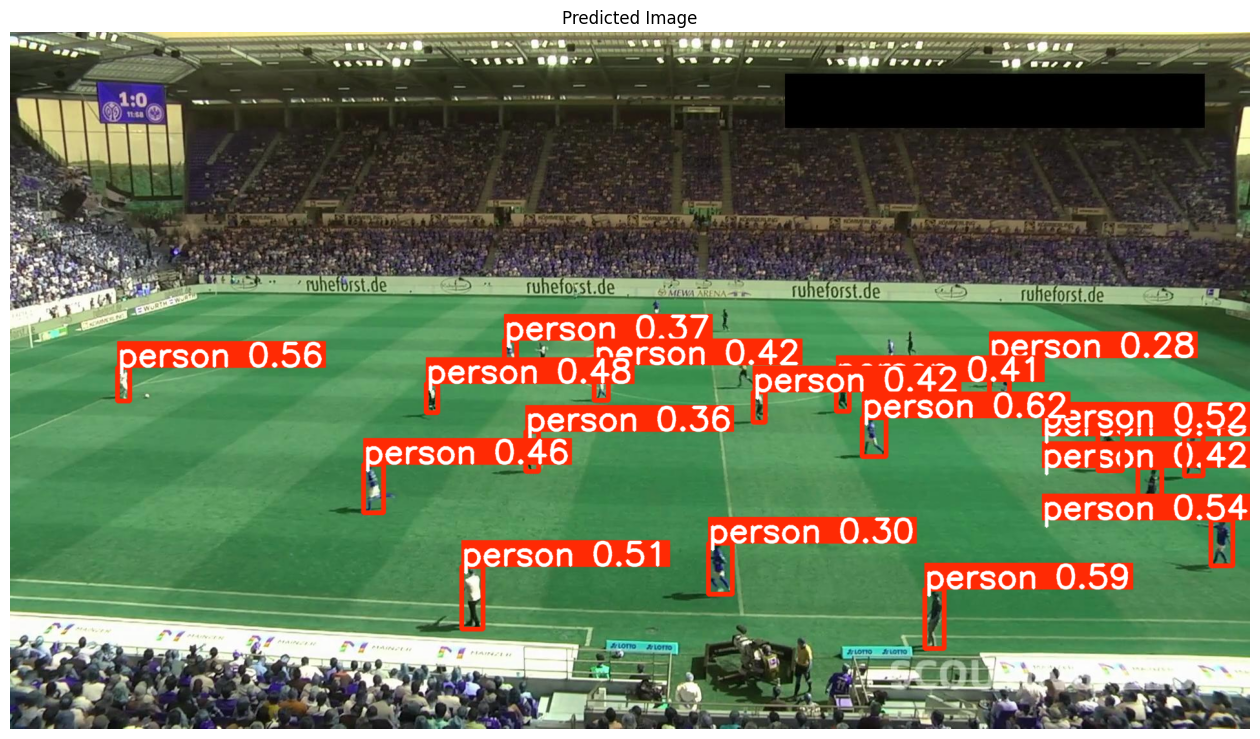

In [ ]:
# Load an image and run inference
results = model(path + '/test/images/40cd38_7_6_png.rf.68ef7fcd663cdf0f5b96bacdbcd94e07.jpg', save=True)

# Convert result to a NumPy array and display
predicted_image = results[0].plot()  # Convert prediction to an image

plt.figure(figsize=(16, 16))
plt.imshow(predicted_image)
plt.axis("off")
plt.title("Predicted Image")

In [ ]:
model.train(data=dataset_path, epochs=10, imgsz=640)

Ultralytics 8.3.200 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/root/.cache/kagglehub/datasets/borhanitrash/football-players-detection-dataset/versions/1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=au

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f6e3afbff80>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [ ]:
metrics = model.val(data=dataset_path)

Ultralytics 8.3.200 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3729.6±656.9 MB/s, size: 215.3 KB)
val: Scanning /root/.cache/kagglehub/datasets/borhanitrash/football-players-detection-dataset/versions/1/valid/labels.cache... 43 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 43/43 92.1Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.0it/s 3.0s
                   all         43       1025      0.711      0.277      0.272      0.166
                  ball         39         39          1          0          0          0
            goalkeeper         32         32          1          0      0.115     0.0528
                player         43        853      0.718      0.931      0.887      0.563
               referee         43        101      0.128      0.178


image 1/1 /root/.cache/kagglehub/datasets/borhanitrash/football-players-detection-dataset/versions/1/test/images/40cd38_7_6_png.rf.68ef7fcd663cdf0f5b96bacdbcd94e07.jpg: 384x640 20 players, 11.5ms
Speed: 2.0ms preprocess, 11.5ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict2


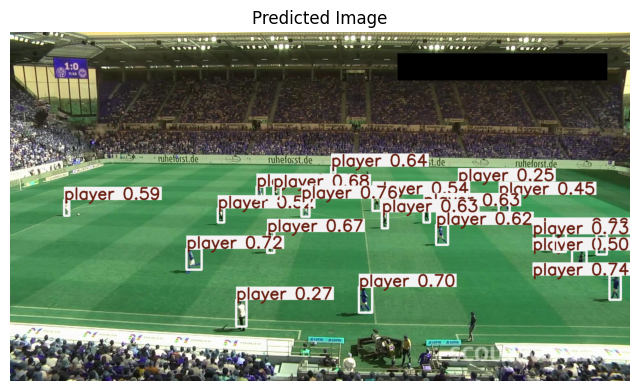

In [ ]:
# Load an image and run inference
model = YOLO(model.trainer.best)  # Use the best weights
results = model(path + "/test/images/40cd38_7_6_png.rf.68ef7fcd663cdf0f5b96bacdbcd94e07.jpg", save=True)

# Convert result to a NumPy array and display
predicted_image = results[0].plot()  # Convert prediction to an image

plt.figure(figsize=(8, 8))
plt.imshow(predicted_image)
plt.axis("off")
plt.title("Predicted Image")
plt.show()
